# BI Copilot — Walmart Sales
**Goal:** Build a Business Intelligence agent with SQL + Plotly visualization on Walmart Sales data

## Libraries

In [1]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain

from langgraph.graph import END, StateGraph
from typing import TypedDict, Optional

import pandas as pd
import sqlalchemy as sql
import plotly.express as px
import plotly.io as pio

import os
import re
import yaml
import json
from pprint import pprint
from IPython.display import Markdown, display

C:\Users\User\AppData\Local\Temp\ipykernel_31380\2369543545.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


## AI Setup

In [2]:
os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 1.0 Database Connection — Walmart Sales

In [3]:
PATH_DB = "sqlite:///../data/walmart_sales.db"

sql_engine = sql.create_engine(PATH_DB)
conn = sql_engine.connect()

db = SQLDatabase.from_uri(PATH_DB)
print("Tables:", db.get_usable_table_names())
print("\nSchema:\n", db.get_table_info())

Tables: ['daily_demand']

Schema:
 
CREATE TABLE daily_demand (
	item_id TEXT, 
	value INTEGER, 
	date TEXT
)

/*
3 rows from daily_demand table:
item_id	value	date
FOODS_3_090	1046	2011-01-29
FOODS_3_090	1036	2011-01-30
FOODS_3_090	673	2011-01-31
*/


## 2.0 Utilities

In [4]:
def extract_sql_code(text: str):
    if not text:
        return None
    m = re.search(r"SQLQuery:\s*```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```[\w]*\s*(SELECT[\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"(SELECT[\s\S]+?)(?:;|\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip().rstrip(';')
    return None
    m = re.search(r"SQLQuery:\s*```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```[\w]*\s*(SELECT[\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"(SELECT[\s\S]+?)(?:;|\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip().rstrip(';')
    return None
    # 1) SQLQuery: ```sql ... ```
    m = re.search(r"SQLQuery:\s*```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 2) ```sql ... ```
    m = re.search(r"```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 3) ``` ... ``` containing SELECT
    m = re.search(r"```[\w]*\s*(SELECT[\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 4) SQLQuery: SELECT ... (no fence)
    m = re.search(r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 5) Bare SELECT ...
    m = re.search(r"(SELECT[\s\S]+?)(?:;|\n\n|$)", text, re.IGNORECASE)
    if m:
        return m.group(1).strip().rstrip(";")
    return None


def extract_python_code(text: str):
    """Extract Python code from LLM text output."""
    m = re.search(r"```python\s*(?P<code>[\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group("code").strip()
    return None

## 3.0 LangGraph BI Agent

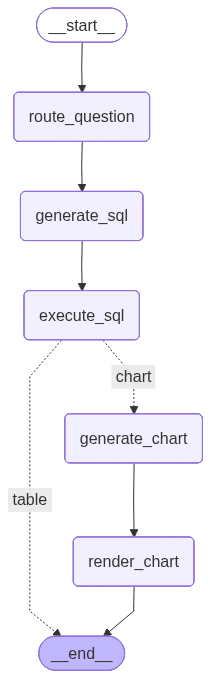

In [5]:
sql_chain = create_sql_query_chain(llm=llm, db=db, k=int(1e7))


class BIState(TypedDict):
    user_question: str
    sql_query: Optional[str]
    data: Optional[list]
    chart_code: Optional[str]
    chart_figure: Optional[object]
    routing_decision: Optional[str]  # 'table' or 'chart'


# --- Node: Route question ---
def route_question(state):
    """Decide whether to return a table or chart."""
    question = state["user_question"]
    prompt = f"""Does the following question ask for a chart/plot/visualization? Answer only 'chart' or 'table'.

Question: {question}"""
    result = llm.invoke(prompt)
    decision = "chart" if "chart" in result.content.lower() else "table"
    print(f"---ROUTING: {decision}---")
    return {"routing_decision": decision}


# --- Node: Generate SQL ---
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state["user_question"]
    raw = sql_chain.invoke({"question": question})
    sql_q = extract_sql_code(raw)
    return {"sql_query": sql_q}


# --- Node: Execute SQL ---
def execute_sql(state):
    print("---EXECUTE SQL---")
    sql_q = state["sql_query"]
    df = pd.read_sql(sql_q, conn)
    return {"data": df.to_dict(orient="records")}


# --- Node: Generate chart ---
def generate_chart(state):
    print("---GENERATE CHART---")
    question = state["user_question"]
    data = state["data"]
    df_sample = pd.DataFrame(data).head(5).to_dict(orient="records")
    
    prompt = f"""You are a data visualization expert. Given the user question and data sample, 
write Python code using plotly.express (imported as px) and pandas (imported as pd) to create a chart.
The data is in a variable called `df` (a pandas DataFrame).
Return ONLY the Python code in a ```python``` block. The figure must be assigned to `fig`.

Question: {question}
Data columns: {list(pd.DataFrame(data).columns)}
Sample rows: {df_sample}"""
    
    result = llm.invoke(prompt)
    code = extract_python_code(result.content)
    return {"chart_code": code}


# --- Node: Render chart ---
def render_chart(state):
    print("---RENDER CHART---")
    code = state.get("chart_code")
    data = state.get("data")
    if code and data:
        df = pd.DataFrame(data)
        local_vars = {"df": df, "px": px, "pd": pd}
        try:
            exec(code, local_vars)
            fig = local_vars.get("fig")
            if fig:
                return {"chart_figure": pio.to_json(fig)}
        except Exception as e:
            print(f"Chart render error: {e}")
    return {"chart_figure": None}


# --- Routing function ---
def should_chart(state):
    return state.get("routing_decision", "table")


# Build workflow
workflow = StateGraph(BIState)
workflow.add_node("route_question", route_question)
workflow.add_node("generate_sql", generate_sql)
workflow.add_node("execute_sql", execute_sql)
workflow.add_node("generate_chart", generate_chart)
workflow.add_node("render_chart", render_chart)

workflow.set_entry_point("route_question")
workflow.add_edge("route_question", "generate_sql")
workflow.add_edge("generate_sql", "execute_sql")
workflow.add_conditional_edges(
    "execute_sql",
    should_chart,
    {"chart": "generate_chart", "table": END},
)
workflow.add_edge("generate_chart", "render_chart")
workflow.add_edge("render_chart", END)

app = workflow.compile()
app

## 4.0 Test: Table Query

In [6]:
result = app.invoke({"user_question": "What tables are in the database?"})
print("SQL:", result.get('sql_query'))
pd.DataFrame(result.get('data', []))

---ROUTING: table---
---GENERATE SQL---


---EXECUTE SQL---
SQL: SELECT name FROM sqlite_master WHERE type='table';


,name
0,daily_demand
1,sqlite_stat1
2,sqlite_stat4


In [7]:
result = app.invoke({"user_question": "What are the top 10 items by total demand value?"})
print("SQL:", result.get('sql_query'))
pd.DataFrame(result.get('data', []))

---ROUTING: table---
---GENERATE SQL---


---EXECUTE SQL---
SQL: SELECT "item_id", SUM("value") AS "total_demand"
FROM daily_demand
GROUP BY "item_id"
ORDER BY "total_demand" DESC
LIMIT 10;


,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


## 5.0 Test: Chart Query

In [8]:
result = app.invoke({
    "user_question": "What are the total sales value by year-month? Make a line chart of sales over time."
})

print("SQL:", result.get('sql_query'))
df_result = pd.DataFrame(result.get('data', []))
display(df_result)

if result.get('chart_figure'):
    fig = pio.from_json(result['chart_figure'])
    fig.show()

---ROUTING: chart---
---GENERATE SQL---


---EXECUTE SQL---
---GENERATE CHART---


---RENDER CHART---


SQL: SELECT strftime('%Y-%m', "date") AS "year_month", SUM("value") AS "total_sales"
FROM "daily_demand"
GROUP BY "year_month"
ORDER BY "year_month";


,year_month,total_sales
0,2011-01,9758
1,2011-02,69217
2,2011-03,64767
3,2011-04,69084
4,2011-05,69958
...,...,...
59,2015-12,70503
60,2016-01,80705
61,2016-02,88471
62,2016-03,89161


In [9]:
result = app.invoke({
    "user_question": "What are the top 10 items by total demand value? Make a horizontal bar chart."
})

print("SQL:", result.get('sql_query'))
df_result = pd.DataFrame(result.get('data', []))
display(df_result)

if result.get('chart_figure'):
    fig = pio.from_json(result['chart_figure'])
    fig.show()

---ROUTING: chart---
---GENERATE SQL---


---EXECUTE SQL---
---GENERATE CHART---


---RENDER CHART---
SQL: SELECT "item_id", SUM("value") AS "total_demand"
FROM daily_demand
GROUP BY "item_id"
ORDER BY "total_demand" DESC
LIMIT 10;


,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333
